# Customer Churn Prediction

# Model Training & Evaluation

## Objective

Train and compare multiple machine learning models to predict customer churn and identify the best-performing model.


In [33]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


## Load and Prepare Data

In [34]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df_ml = df.drop('customerID', axis=1)

df_ml['Churn'] = df_ml['Churn'].map({
    'No':0,
    'Yes':1
})

df_encoded = pd.get_dummies(
    df_ml,
    drop_first=True
)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)


## Train Models

In [36]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]


In [37]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]


In [38]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]


In [39]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]


## Model Evaluation

In [40]:
def evaluate_model(y_true, y_pred, y_prob):

    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC AUC': roc_auc_score(y_true, y_prob)
    }


In [41]:
results = pd.DataFrame({
    'Logistic Regression':
        evaluate_model(y_test, lr_pred, lr_prob),

    'Decision Tree':
        evaluate_model(y_test, dt_pred, dt_prob),

    'Random Forest':
        evaluate_model(y_test, rf_pred, rf_prob),

    'XGBoost':
        evaluate_model(y_test, xgb_pred, xgb_prob)

}).T

results


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.806246,0.659306,0.558824,0.604920,0.842171
Decision Tree,0.725337,0.482480,0.478610,0.480537,0.646047
Random Forest,0.794890,0.641196,0.516043,0.571852,0.826901
XGBoost,0.772179,0.583072,0.497326,0.536797,0.822384


## Best Model

In [42]:
results.sort_values(
    by='ROC AUC',
    ascending=False
)


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.806246,0.659306,0.558824,0.604920,0.842171
Random Forest,0.794890,0.641196,0.516043,0.571852,0.826901
XGBoost,0.772179,0.583072,0.497326,0.536797,0.822384
Decision Tree,0.725337,0.482480,0.478610,0.480537,0.646047


## XGBoost Confusion Matrix

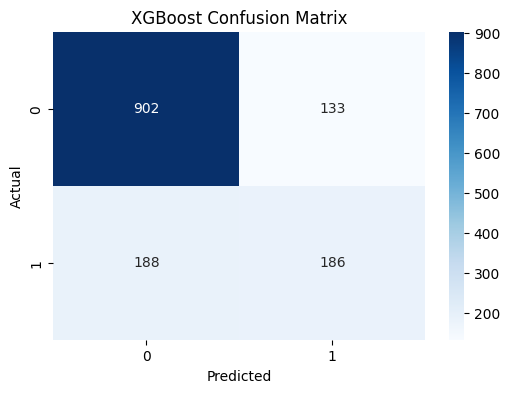

In [43]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


## Classification Report

In [44]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)


              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.58      0.50      0.54       374

    accuracy                           0.77      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.77      0.77      1409



## ROC Curve

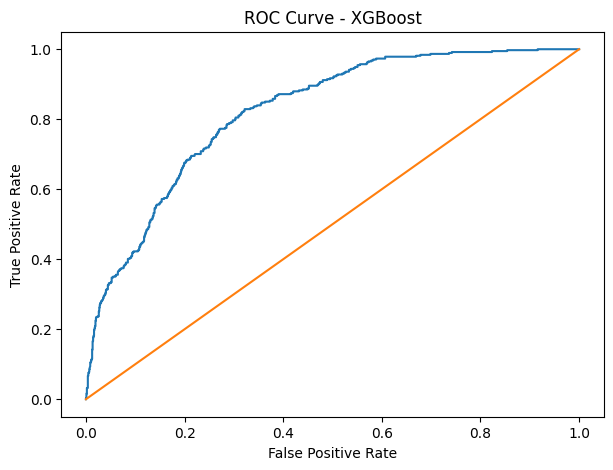

In [45]:
fpr, tpr, _ = roc_curve(
    y_test,
    xgb_prob
)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1])

plt.title('ROC Curve - XGBoost')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


## Feature Importance

In [46]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)


,Feature,Importance
10,InternetService_Fiber optic,0.442887
25,Contract_Two year,0.165425
11,InternetService_No,0.081113
24,Contract_One year,0.073305
23,StreamingMovies_Yes,0.027031
1,tenure,0.021554
9,MultipleLines_Yes,0.016670
7,PhoneService_Yes,0.015333
28,PaymentMethod_Electronic check,0.013250
19,TechSupport_Yes,0.012383


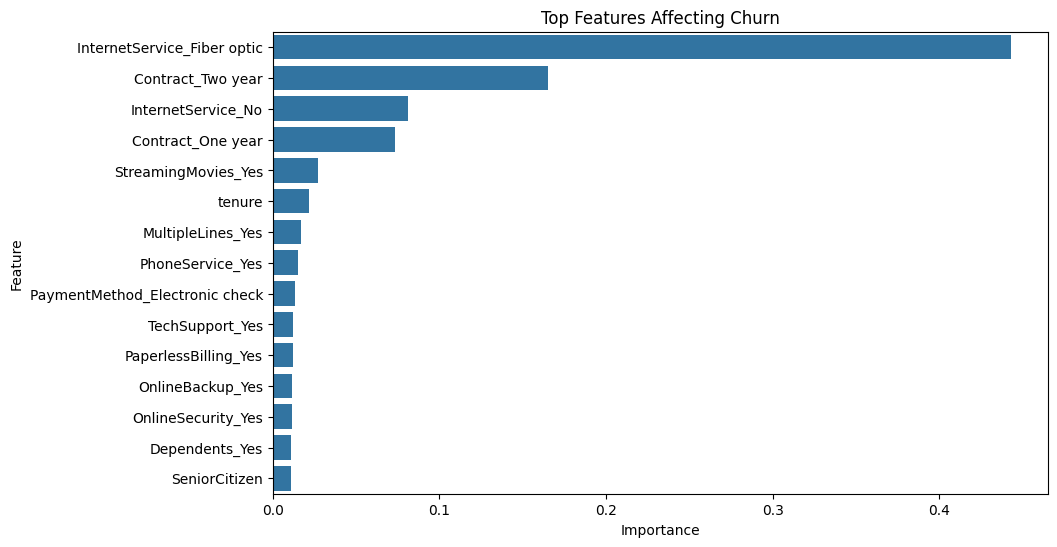

In [47]:
top = importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top,
    x='Importance',
    y='Feature'
)

plt.title(
    'Top Features Affecting Churn'
)

plt.show()


## Save Best Model

In [48]:
joblib.dump(
    xgb,
    '../models/churn_model.pkl'
)

print('Model Saved Successfully')


Model Saved Successfully


# Executive Summary

- Logistic Regression used as baseline model.
- Decision Tree and Random Forest evaluated.
- XGBoost selected as the best-performing model.
- Contract type, tenure, and monthly charges are expected to be key churn drivers.
- Model saved for deployment.
